In [ ]:
from google.colab import files
# eim_1d_by_tick_v8_weighted_general_topic_general_narrative.json
uploaded = files.upload()

Saving eim_1d_by_tick_v8_weighted_general_topic_general_narrative.json to eim_1d_by_tick_v8_weighted_general_topic_general_narrative.json


In [ ]:
import json

# Load weighted PCA Data
with open('eim_1d_by_tick_v8_weighted_general_topic_general_narrative.json', 'r') as f:
    weighted_raw = json.load(f)

# {int: float} Dictionary
eim_1d_by_tick = {int(k): float(v) for k, v in weighted_raw.items()}

max_tick = max(eim_1d_by_tick)
min_tick = min(eim_1d_by_tick)

# Get EIM signal for a tick; use boundary value if out of range
def get_eim_signal(tick):
    if tick < min_tick:
        return eim_1d_by_tick[min_tick]
    if tick > max_tick:
        return eim_1d_by_tick[max_tick]
    return eim_1d_by_tick[tick]

print(f"Tick range: {min_tick} ~ {max_tick}")
print(f"Total {len(eim_1d_by_tick)} ticks")
print(f"Value at Tick 699 (2021-01-02): {get_eim_signal(699):.4f}")
print(f"Value at Tick 1606 (2023-12-25): {get_eim_signal(1606):.4f}")

Tick range: 1 ~ 1606
Total 1606 ticks
Value at Tick 699 (2021-01-02): -0.5890
Value at Tick 1606 (2023-12-25): 0.3009


Enhanced Polarization Model
Agent Zero++ | ACT-R Memory | Schelling Segregation

[Running 907 ticks, from tick 699 to 1606...]
Step 200/907, Model tick: 899
Step 400/907, Model tick: 1099
Step 600/907, Model tick: 1299
Step 800/907, Model tick: 1499

FINAL STATE

Tick: 1606  |  Day: 453

Economic:
  Cost of Goods: $674664.06
  Employed: 42
  Unhoused: 8

Agent States:
  Quiet: 0
  Agitated: 5
  Fight: 4
  Flight: 41

Opinions:
  Mean: 0.0490
  Std:  0.3798
  Range: [-0.7831, 0.7415]

Disposition:
  Mean: 0.2191
  Max:  0.6762

Network:
  Avg connections: 4.12
  Homophily: 0.9455

Sample Agents (tick 1606):
  Agent 0: opinion=0.491, affect=0.436, disp=0.111, tau=0.605, state=flight
  Agent 1: opinion=-0.020, affect=0.460, disp=0.252, tau=0.361, state=flight
  Agent 2: opinion=-0.376, affect=0.347, disp=0.303, tau=0.515, state=flight
  Agent 3: opinion=-0.480, affect=0.363, disp=0.228, tau=0.545, state=flight
  Agent 4: opinion=-0.141, affect=0.356, disp=0.113, tau=0.391, state=flight
  

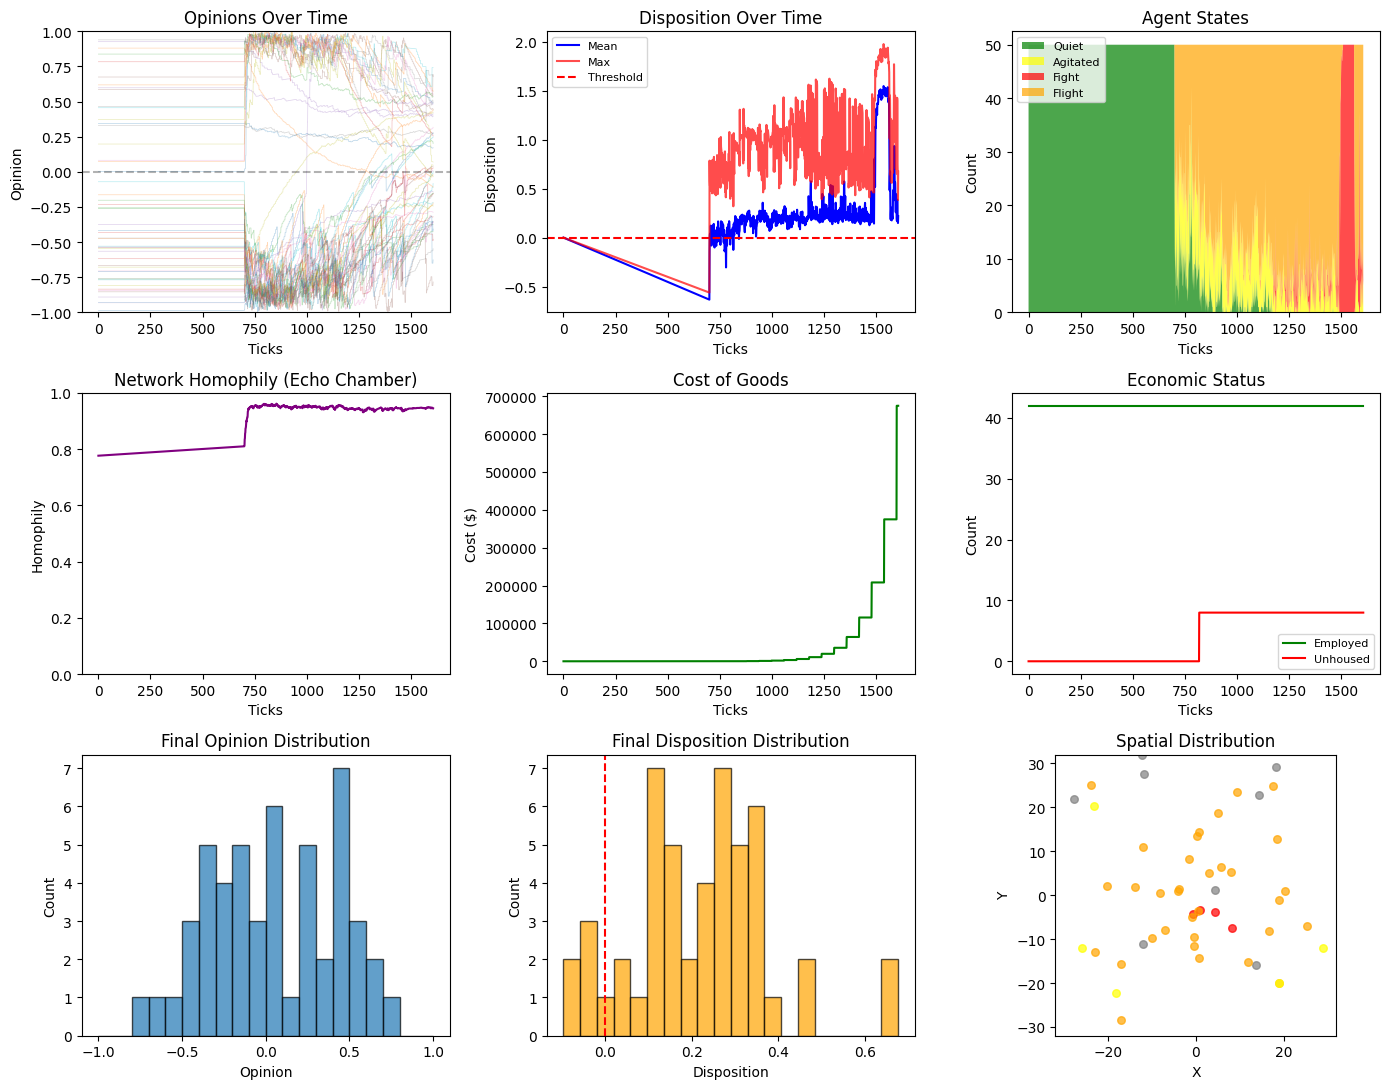

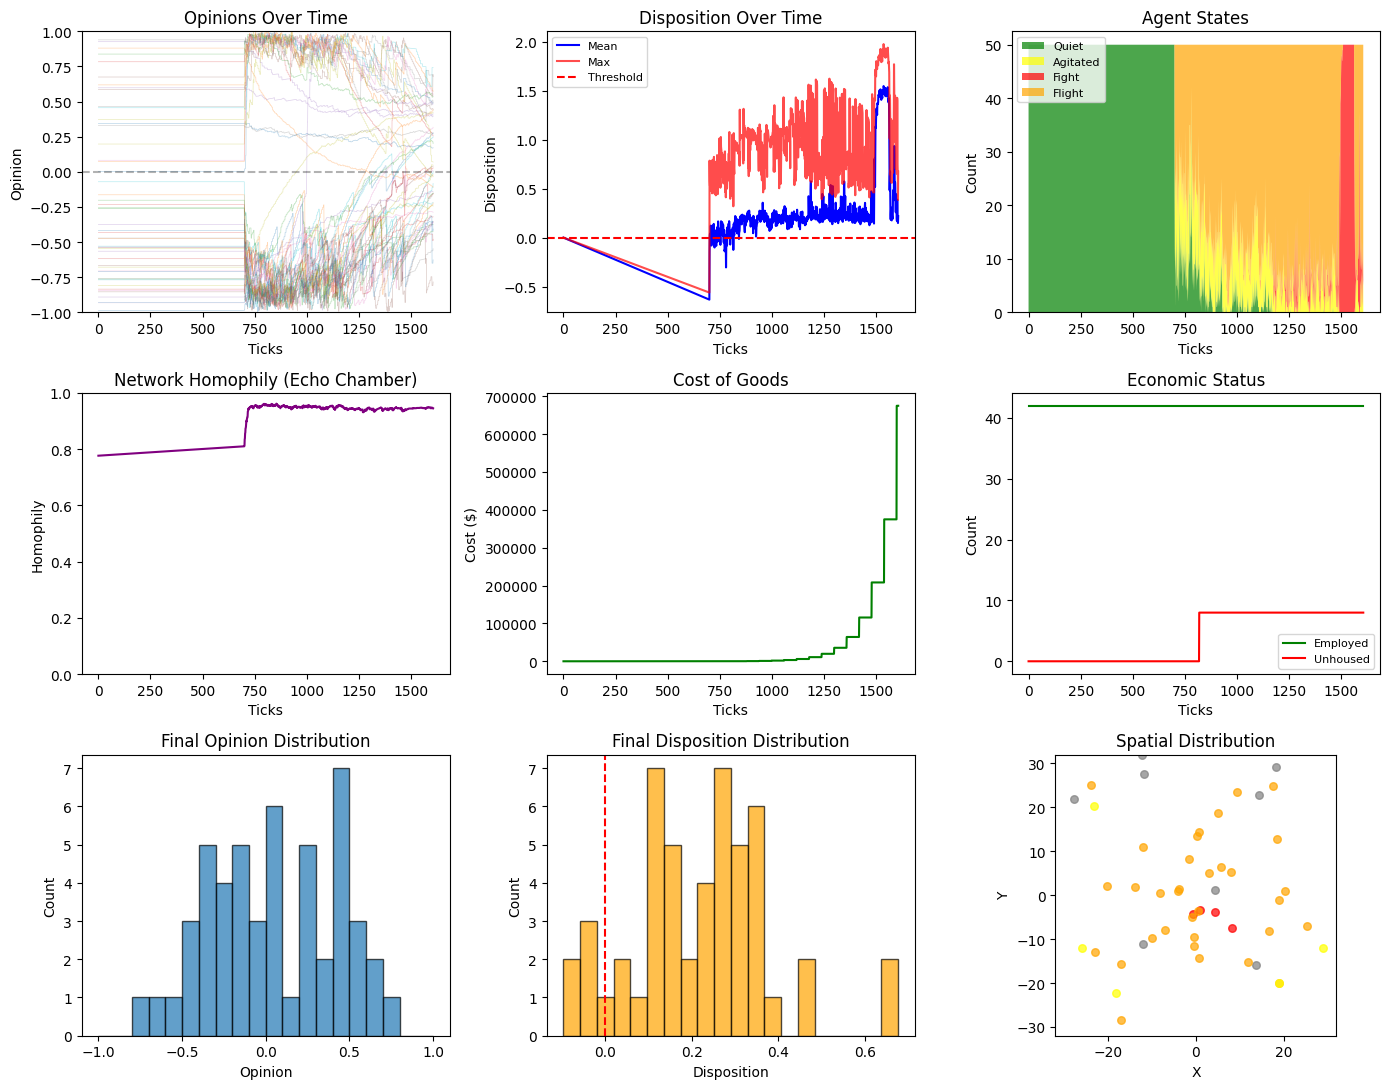

In [ ]:
"""
New features:
- Agent Zero++ disposition model (A + P + C - threshold)
- ACT-R memory system for info processing
- Schelling segregation (network rewiring)
- Info sources with stance broadcasting + trust
- Economic stress -> conflict threshold linkage
- Fight/flight behavior when disposition > threshold
"""

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, List, Dict
from collections import defaultdict
from enum import Enum


class AgentState(Enum):
    # behavioral states from Agent Zero++
    QUIET = "quiet"
    AGITATED = "agitated"
    FIGHT = "fight"      # protesting/violent
    FLIGHT = "flight"    # fleeing/avoiding


class InfoSourceType(Enum):
    GOVWEBSITE = "govwebsite"
    X = "X"
    REDDIT = "reddit"
    FACEBOOK = "facebook"


# parameters

@dataclass
class ModelParameters:
    # population
    num_people: int = 50
    homes_per_quadrant: int = 3

    # bounded confidence thresholds
    threshold_pos: float = 0.4
    threshold_neg: float = 0.6

    # schelling segregation params
    segregation_tolerance: float = 0.3   # max opinion diff tolerated in network
    rewire_prob: float = 0.1             # prob of cutting dissimilar ties

    # economic params
    increase_cost_of_goods: bool = True
    cost_of_goods_growth_rate: float = 1.8

    # info source weights (for random assignment)
    parts_govwebsite: int = 5
    parts_x: int = 3
    parts_reddit: int = 4
    parts_facebook: int = 3

    # Agent Zero++ params
    # base conflict threshold - action triggered when disposition > tau
    tau_base: float = 0.6
    # younger agents have lower threshold (more impulsive)
    tau_age_factor: float = 0.005
    # economic stress lowers threshold
    tau_economic_factor: float = 0.2

    # ACT-R memory decay parameter (typically 0.5 in literature)
    memory_decay: float = 0.5

    # how often info sources broadcast
    broadcast_interval: int = 10

    # initial social network connections per agent
    initial_connections: int = 5


# ACT-R memory system
# Simplified ACT-R base-level learning for memory activation.
# The idea: memories decay over time, but repeated exposure keeps them active.
# Activation = ln(sum of t^(-d) for each exposure time t)
# High activation = agent remembers/believes the info strongly
# Low activation = agent has mostly forgotten it

class ACTRMemory:

    def __init__(self, decay=0.5):
        self.decay = decay
        # tracks when agent was exposed to each piece of info
        # {info_id: [tick1, tick2, ...]}
        self.exposures = defaultdict(list)

    # record that agent saw this info at this tick
    def add_exposure(self, info_id, current_tick):
        self.exposures[info_id].append(current_tick)

    # calculate activation level using ACT-R equation:
    # A = ln(sum(t_j^(-d)))
    # returns roughly -5 to 5, higher = more active/memorable
    def get_activation(self, info_id, current_tick):
        if info_id not in self.exposures:
            return float('-inf')  # never seen

        times = self.exposures[info_id]
        if not times:
            return float('-inf')

        total = 0.0
        for t in times:
            time_since = max(1, current_tick - t)  # avoid div by zero
            total += time_since ** (-self.decay)

        return np.log(total) if total > 0 else float('-inf')

    # average activation across all stored memories
    def get_avg_activation(self, current_tick):
        if not self.exposures:
            return 0.0

        activations = []
        for info_id in self.exposures:
            a = self.get_activation(info_id, current_tick)
            if a > float('-inf'):
                activations.append(a)

        if not activations:
            return 0.0

        # normalize to roughly [0, 1]
        avg = np.mean(activations)
        return np.clip((avg + 5) / 10, 0, 1)

# data classes

@dataclass
class Location:
    x: int
    y: int
    location_type: str = "empty"

    def __hash__(self):
        return hash((self.x, self.y))

    def __eq__(self, other):
        if other is None:
            return False
        return self.x == other.x and self.y == other.y


# Info sources that broadcast stance values.
# Different sources have different stances and credibility.
@dataclass
class InfoSource:
    source_id: str
    source_type: InfoSourceType
    x: int
    y: int
    stance: float = 0.0        # -1 to +1, the opinion being pushed
    credibility: float = 0.5   # how believable (0 to 1)

    # generate a message id for this broadcast
    def broadcast(self, tick):
        msg_id = f"{self.source_id}_t{tick}"
        return msg_id, self.stance


# Agent with Agent Zero++ cognitive architecture.
# The disposition formula (from Epstein's Agent Zero):
# D = A + P + C - tau
# where:
# - A = Affect (emotional arousal)
# - P = Probability (perceived risk/threat)
# - C = Contagion (social influence from network)
# - tau = threshold (varies by age, economic status)
# Action triggered when D > 0 (i.e., A + P + C > tau)

@dataclass
class Person:
    unique_id: int

    # demographics
    age: int = 0
    employed: bool = False
    income: float = 0.0
    savings: float = 1000.0
    rent: float = 500.0
    unhoused: bool = False

    # spatial
    x: float = 0.0
    y: float = 0.0
    home_location: Optional[Location] = None
    work_location: Optional[Location] = None
    school_location: Optional[Location] = None

    # opinion dynamics (bounded confidence)
    opinion: float = 0.0
    gamma: float = 0.0  # learning rate
    threshold_pos: float = 0.4
    threshold_neg: float = 0.6

    # info consumption
    info_preference: str = "govwebsite"
    # trust in each source type (0 to 1)
    trust_gov: float = 0.7
    trust_x: float = 0.5
    trust_reddit: float = 0.5
    trust_facebook: float = 0.4

    # Agent Zero++ variables
    affect: float = 0.0           # A: emotional arousal
    probability: float = 0.0      # P: perceived risk
    contagion: float = 0.0        # C: social influence
    disposition: float = 0.0      # D = A + P + C - tau
    tau: float = 0.6              # action threshold

    # impulse control (from age) - lower = more impulsive
    impulse_control: float = 1.0

    # behavioral state
    state: AgentState = AgentState.QUIET

    # social network (list of connected agent ids)
    connections: List[int] = field(default_factory=list)

    # memory system
    memory: Optional[ACTRMemory] = None

    # schelling happiness (are my network neighbors similar enough?)
    is_happy: bool = True

    # track threat memory for P calculation (rolling window)
    threat_memory: List[float] = field(default_factory=list)
    memory_window: int = 10

    def __post_init__(self):
        if self.memory is None:
            self.memory = ACTRMemory()
        if not self.threat_memory:
            self.threat_memory = []

    # get trust level for a source type
    def get_trust(self, source_type):
        trust_map = {
            InfoSourceType.GOVWEBSITE: self.trust_gov,
            InfoSourceType.X: self.trust_x,
            InfoSourceType.REDDIT: self.trust_reddit,
            InfoSourceType.FACEBOOK: self.trust_facebook,
        }
        return trust_map.get(source_type, 0.5)

    # update P using rolling memory average (from Agent Zero++)
    # P = (1/m) * sum of recent threat observations
    def update_probability(self, current_threat):
        self.threat_memory.append(current_threat)
        if len(self.threat_memory) > self.memory_window:
            self.threat_memory.pop(0)
        self.probability = np.mean(self.threat_memory) if self.threat_memory else 0

    # Agent Zero++ disposition formula:
    # D = (A + P + C) * opinion_amplifier - tau
    # The opinion amplifier is my addition - extreme opinions
    # make you more reactive (based on motivational salience theory)
    def calculate_disposition(self, current_tick):
        # core Agent Zero++ components
        A = self.affect
        P = self.probability
        C = self.contagion

        # memory contribution (from ACT-R)
        E = self.memory.get_avg_activation(current_tick) if self.memory else 0

        # opinion extremity as amplifier
        # theory: people with extreme views react more strongly
        beta = 0.3
        amplifier = 1 + beta * abs(self.opinion)

        # final disposition
        self.disposition = (A + P + C + E * 0.2) * amplifier - self.tau
        return self.disposition

    # update behavioral state based on disposition
    # from Agent Zero++:
    # - D > 0 and high affect -> FIGHT
    # - D > 0 and lower affect -> FLIGHT
    # - D close to 0 -> AGITATED
    # - D < 0 -> QUIET
    def update_state(self):
        if self.disposition > 0:
            # above threshold - fight or flight
            if self.affect > 0.5:
                self.state = AgentState.FIGHT
            else:
                self.state = AgentState.FLIGHT
        elif self.disposition > -0.2:
            self.state = AgentState.AGITATED
        else:
            self.state = AgentState.QUIET

    # for visualization
    def get_color(self):
        colors = {
            AgentState.QUIET: 'green',
            AgentState.AGITATED: 'yellow',
            AgentState.FIGHT: 'red',
            AgentState.FLIGHT: 'orange',
        }
        if self.unhoused:
            return 'gray'
        return colors.get(self.state, 'blue')


# data collector
# tracks all the metrics

class DataCollector:

    def __init__(self):
        self.reset()

    def reset(self):
        self.ticks = []
        self.days = []
        self.cost_of_goods = []

        # per-agent tracking
        self.agent_opinions = defaultdict(list)
        self.agent_dispositions = defaultdict(list)
        self.agent_affects = defaultdict(list)
        self.agent_states = defaultdict(list)

        # info preferences
        self.info_pref_counts = defaultdict(list)

        # population status
        self.count_employed = []
        self.count_unhoused = []

        # agent states
        self.count_quiet = []
        self.count_agitated = []
        self.count_fight = []
        self.count_flight = []

        # opinion stats
        self.opinion_mean = []
        self.opinion_std = []
        self.opinion_min = []
        self.opinion_max = []

        # disposition stats
        self.disposition_mean = []
        self.disposition_max = []

        # network stats
        self.avg_connections = []
        self.network_homophily = []

    # grab current state from model
    def collect(self, model):
        self.ticks.append(model.tick)
        self.days.append(model.day_counter)
        self.cost_of_goods.append(model.cost_of_goods)

        opinions = []
        dispositions = []
        state_counts = {s: 0 for s in AgentState}
        pref_counts = {"govwebsite": 0, "X": 0, "reddit": 0, "facebook": 0}

        total_connections = 0
        homophily_sum = 0
        homophily_n = 0

        for p in model.people:
            # per-agent data
            self.agent_opinions[p.unique_id].append(p.opinion)
            self.agent_dispositions[p.unique_id].append(p.disposition)
            self.agent_affects[p.unique_id].append(p.affect)
            self.agent_states[p.unique_id].append(p.state.value)

            opinions.append(p.opinion)
            dispositions.append(p.disposition)
            state_counts[p.state] += 1
            pref_counts[p.info_preference] += 1

            # network stats
            total_connections += len(p.connections)
            for cid in p.connections:
                if cid < len(model.people):
                    other = model.people[cid]
                    similarity = 1 - abs(p.opinion - other.opinion) / 2
                    homophily_sum += similarity
                    homophily_n += 1

        # aggregate stats
        self.opinion_mean.append(np.mean(opinions))
        self.opinion_std.append(np.std(opinions))
        self.opinion_min.append(np.min(opinions))
        self.opinion_max.append(np.max(opinions))

        self.disposition_mean.append(np.mean(dispositions))
        self.disposition_max.append(np.max(dispositions))

        self.count_quiet.append(state_counts[AgentState.QUIET])
        self.count_agitated.append(state_counts[AgentState.AGITATED])
        self.count_fight.append(state_counts[AgentState.FIGHT])
        self.count_flight.append(state_counts[AgentState.FLIGHT])

        for pref, cnt in pref_counts.items():
            self.info_pref_counts[pref].append(cnt)

        self.count_employed.append(sum(1 for p in model.people if p.employed))
        self.count_unhoused.append(sum(1 for p in model.people if p.unhoused))

        n_people = len(model.people) if model.people else 1
        self.avg_connections.append(total_connections / n_people)
        self.network_homophily.append(homophily_sum / homophily_n if homophily_n > 0 else 0)

    # export to dataframe
    def get_summary_df(self):
        return pd.DataFrame({
            "tick": self.ticks,
            "day": self.days,
            "cost_of_goods": self.cost_of_goods,
            "opinion_mean": self.opinion_mean,
            "opinion_std": self.opinion_std,
            "opinion_min": self.opinion_min,
            "opinion_max": self.opinion_max,
            "disposition_mean": self.disposition_mean,
            "disposition_max": self.disposition_max,
            "count_quiet": self.count_quiet,
            "count_agitated": self.count_agitated,
            "count_fight": self.count_fight,
            "count_flight": self.count_flight,
            "count_employed": self.count_employed,
            "count_unhoused": self.count_unhoused,
            "avg_connections": self.avg_connections,
            "homophily": self.network_homophily,
        })


# main model
# Enhanced model with all the improvements:
# 1. Agent Zero++ (A + P + C -> disposition -> action)
# 2. ACT-R memory
# 3. Schelling network segregation
# 4. Info broadcast with trust
# 5. Economic stress -> threshold

class EnhancedPolarizationModel:
    def __init__(self, params=None):
        self.params = params or ModelParameters()

        # state
        self.tick = 0
        self.day_counter = 0
        self.cost_of_goods = 100.0

        # agents
        self.people: List[Person] = []
        self.info_sources: List[InfoSource] = []

        # locations
        self.work_locations = []
        self.school_locations = []
        self.home_locations = []

        # grid
        self.min_coord = -32
        self.max_coord = 32

        self.data = DataCollector()
        self.is_setup = False

    # initialize everything
    def setup(self):
        self.tick = 0
        self.day_counter = 0
        self.cost_of_goods = 100.0

        self.people = []
        self.info_sources = []
        self.data.reset()

        self._setup_info_sources()
        self._setup_locations()
        self._create_people()
        self._create_social_network()

        self.data.collect(self)
        self.is_setup = True

    # create info sources with different stances
    # this is where disinformation can come from
    def _setup_info_sources(self):
        # configure each source's stance and credibility
        configs = [
            ("A", InfoSourceType.GOVWEBSITE, 0.0, 0.8),   # neutral, high cred
            ("B", InfoSourceType.X, 0.6, 0.4),            # pro-stance, lower cred
            ("C", InfoSourceType.REDDIT, -0.5, 0.5),      # anti-stance
            ("D", InfoSourceType.FACEBOOK, 0.8, 0.5),     # strong pro (disinfo)
        ]

        y = self.max_coord - 1
        for sid, stype, stance, cred in configs:
            x = random.randint(self.min_coord, self.max_coord)
            self.info_sources.append(InfoSource(
                source_id=sid,
                source_type=stype,
                x=x, y=y,
                stance=stance,
                credibility=cred
            ))

    # create work, school, home in each quadrant
    def _setup_locations(self):
        quadrants = [
            (self.min_coord, -1, self.min_coord, -1),
            (0, self.max_coord, self.min_coord, -1),
            (self.min_coord, -1, 0, self.max_coord),
            (0, self.max_coord, 0, self.max_coord),
        ]

        used = set()

        # workplaces
        for xmin, xmax, ymin, ymax in quadrants:
            loc = self._rand_loc(xmin, xmax, ymin, ymax, used)
            loc.location_type = "work"
            self.work_locations.append(loc)
            used.add((loc.x, loc.y))

        # schools
        for xmin, xmax, ymin, ymax in quadrants:
            loc = self._rand_loc(xmin, xmax, ymin, ymax, used)
            loc.location_type = "school"
            self.school_locations.append(loc)
            used.add((loc.x, loc.y))

        # homes
        for xmin, xmax, ymin, ymax in quadrants:
            for _ in range(self.params.homes_per_quadrant):
                loc = self._rand_loc(xmin, xmax, ymin, ymax, used)
                loc.location_type = "home"
                self.home_locations.append(loc)
                used.add((loc.x, loc.y))

    # find unused random location
    def _rand_loc(self, xmin, xmax, ymin, ymax, used):
        for _ in range(1000):
            x, y = random.randint(xmin, xmax), random.randint(ymin, ymax)
            if (x, y) not in used:
                return Location(x=x, y=y)
        return Location(x=random.randint(xmin, xmax), y=random.randint(ymin, ymax))

    def _create_people(self):
        # calc info preference probabilities
        total = (self.params.parts_govwebsite + self.params.parts_x +
                self.params.parts_reddit + self.params.parts_facebook)
        p_gov = self.params.parts_govwebsite / total
        p_x = self.params.parts_x / total
        p_reddit = self.params.parts_reddit / total

        for i in range(self.params.num_people):
            p = Person(unique_id=i)
            p.memory = ACTRMemory(decay=self.params.memory_decay)

            # demographics
            p.age = random.randint(18, 65)
            p.savings = 1000.0
            p.rent = 500.0

            # opinion
            p.opinion = random.uniform(-1, 1)
            p.gamma = random.uniform(0.1, 0.5)
            p.threshold_pos = self.params.threshold_pos
            p.threshold_neg = self.params.threshold_neg

            # trust levels (some randomness around defaults)
            p.trust_gov = np.clip(random.gauss(0.7, 0.15), 0.1, 1.0)
            p.trust_x = np.clip(random.gauss(0.5, 0.2), 0.1, 1.0)
            p.trust_reddit = np.clip(random.gauss(0.5, 0.2), 0.1, 1.0)
            p.trust_facebook = np.clip(random.gauss(0.4, 0.2), 0.1, 1.0)

            # impulse control from age (Agent Zero++)
            # younger = lower impulse control = lower threshold
            p.impulse_control = 1.0 - (p.age - 18) / 100

            # base threshold adjusted by age
            p.tau = self.params.tau_base + (p.age - 18) * self.params.tau_age_factor

            # location
            p.home_location = random.choice(self.home_locations)
            p.x, p.y = p.home_location.x, p.home_location.y

            # employment (adults only)
            if random.random() < 0.8:
                p.employed = True
                p.income = 2000.0
                p.work_location = random.choice(self.work_locations)

            # info preference
            r = random.random()
            if r < p_gov:
                p.info_preference = "govwebsite"
            elif r < p_gov + p_x:
                p.info_preference = "X"
            elif r < p_gov + p_x + p_reddit:
                p.info_preference = "reddit"
            else:
                p.info_preference = "facebook"

            self.people.append(p)

    # create initial social network with homophily
    # agents more likely to connect with similar opinions
    def _create_social_network(self):
        for p in self.people:
            others = [o for o in self.people if o.unique_id != p.unique_id]

            # sort by opinion similarity
            others.sort(key=lambda x: abs(x.opinion - p.opinion))

            # connect to some similar + some random
            n_similar = self.params.initial_connections // 2
            n_random = self.params.initial_connections - n_similar

            connections = set()

            # similar ones
            for o in others[:n_similar]:
                connections.add(o.unique_id)

            # random ones
            if len(others) > n_similar:
                random_pool = others[n_similar:]
                for o in random.sample(random_pool, min(n_random, len(random_pool))):
                    connections.add(o.unique_id)

            p.connections = list(connections)

    # one simulation tick
    def step(self):
        if not self.is_setup:
            return

        # 1. info broadcast (periodic)
        if self.tick % self.params.broadcast_interval == 0:
            self._broadcast_info()

        # 2. movement
        self._move_people()

        # 3. opinion interactions (bounded confidence)
        self._workplace_interactions()

        # 4. schelling network update
        self._update_network()

        # 5. update Agent Zero++ components
        self._update_agent_zero()

        # 6. economic updates
        if self.tick % 2 == 0:
            self.day_counter += 1
            if self.day_counter % 30 == 0:
                self._monthly_econ()

        self.tick += 1
        self.data.collect(self)

    # info sources push their stance to agents
    # this is the disinformation mechanism
    def _broadcast_info(self):
        for src in self.info_sources:
            msg_id, stance = src.broadcast(self.tick)

            for p in self.people:
                # check if agent follows this source
                pref_match = (p.info_preference == src.source_type.value)

                # also some chance to see it anyway (algorithmic exposure)
                if pref_match or random.random() < 0.2:
                    # get trust for this source
                    trust = p.get_trust(src.source_type)

                    # record in ACT-R memory
                    p.memory.add_exposure(msg_id, self.tick)

                    # update affect based on message
                    # if message aligns with opinion -> confirmation -> affect up
                    # if message opposes opinion -> outrage -> affect up even more
                    alignment = 1 - abs(p.opinion - stance)

                    affect_delta = trust * src.credibility * 0.1
                    if alignment < 0.3:
                        # message opposes my view -> outrage
                        affect_delta *= 2.0
                    elif alignment > 0.7:
                        # message confirms my view -> validation
                        affect_delta *= 1.5

                    # extreme stances trigger more reaction
                    affect_delta *= (1 + abs(stance))

                    p.affect = np.clip(p.affect + affect_delta, 0, 1)

                    # also nudge opinion toward source (if trusted)
                    opinion_shift = trust * src.credibility * (stance - p.opinion) * 0.05
                    p.opinion = np.clip(p.opinion + opinion_shift, -1, 1)

                    # update threat perception
                    # more extreme = more threatening environment
                    threat = abs(stance) * trust * 0.5
                    p.update_probability(threat)

    def _move_people(self):
        for p in self.people:
            if p.unhoused or p.state == AgentState.FLIGHT:
                # random walk
                angle = random.uniform(0, 2 * np.pi)
                p.x = np.clip(p.x + np.cos(angle) * 2, self.min_coord, self.max_coord)
                p.y = np.clip(p.y + np.sin(angle) * 2, self.min_coord, self.max_coord)

            elif p.state == AgentState.FIGHT:
                # move toward center (gathering for protest)
                p.x *= 0.95
                p.y *= 0.95

            elif p.employed:
                # commute
                loc = p.work_location if self.tick % 2 == 0 else p.home_location
                if loc:
                    p.x, p.y = loc.x, loc.y

    # bounded confidence at workplaces
    def _workplace_interactions(self):
        workers_at = defaultdict(list)
        for p in self.people:
            if p.employed and not p.unhoused and p.work_location:
                if int(p.x) == p.work_location.x and int(p.y) == p.work_location.y:
                    workers_at[(p.work_location.x, p.work_location.y)].append(p)

        for workers in workers_at.values():
            if len(workers) < 2:
                continue
            for person in workers:
                others = [w for w in workers if w.unique_id != person.unique_id]
                if others:
                    partner = random.choice(others)
                    self._interact(person, partner)

    def _interact(self, p1, p2):
        diff = abs(p1.opinion - p2.opinion)

        if diff <= p1.threshold_pos:
            # converge
            x1, x2 = p1.opinion, p2.opinion
            p1.opinion = np.clip(x1 + p1.gamma * (x2 - x1), -1, 1)
            p2.opinion = np.clip(x2 + p2.gamma * (x1 - x2), -1, 1)

        if diff >= p1.threshold_neg:
            # diverge (polarize)
            x1, x2 = p1.opinion, p2.opinion
            g1, g2 = p1.gamma, p2.gamma

            if x1 > x2:
                new1 = x1 + (g1/2) * (x1-x2) * (1-x1)
                new2 = x2 + (g2/2) * (x2-x1) * (1+x2)
            else:
                new1 = x1 + (g1/2) * (x1-x2) * (1+x1)
                new2 = x2 + (g2/2) * (x2-x1) * (1-x2)

            p1.opinion = np.clip(new1, -1, 1)
            p2.opinion = np.clip(new2, -1, 1)

    # schelling segregation on social network
    # cut ties with dissimilar agents, form new ties with similar ones
    # this creates echo chambers over time
    def _update_network(self):
        for p in self.people:
            # find unhappy connections (too different)
            unhappy = []
            for cid in p.connections:
                if cid < len(self.people):
                    other = self.people[cid]
                    if abs(p.opinion - other.opinion) > self.params.segregation_tolerance:
                        unhappy.append(cid)

            # maybe rewire unhappy connections
            for cid in unhappy:
                if random.random() < self.params.rewire_prob:
                    p.connections.remove(cid)

                    # find similar agent to connect with
                    candidates = [
                        o for o in self.people
                        if o.unique_id != p.unique_id
                        and o.unique_id not in p.connections
                        and abs(o.opinion - p.opinion) <= self.params.segregation_tolerance
                    ]

                    if candidates:
                        new_friend = random.choice(candidates)
                        p.connections.append(new_friend.unique_id)

            # update happiness
            if p.connections:
                similar = sum(
                    1 for cid in p.connections
                    if cid < len(self.people) and
                    abs(self.people[cid].opinion - p.opinion) <= self.params.segregation_tolerance
                )
                p.is_happy = (similar / len(p.connections)) >= 0.5

    # update Agent Zero++ components for all agents:
    # - contagion from network
    # - decay affect
    # - adjust threshold by economic status
    # - calculate disposition
    # - update behavioral state
    def _update_agent_zero(self):
        for p in self.people:
            # contagion: how many network neighbors are agitated/fighting?
            if p.connections:
                active_neighbors = sum(
                    1 for cid in p.connections
                    if cid < len(self.people) and
                    self.people[cid].state in [AgentState.AGITATED, AgentState.FIGHT]
                )
                p.contagion = active_neighbors / len(p.connections)
            else:
                p.contagion = 0

            # affect decay
            external_affect = get_eim_signal(self.tick)
            alpha = 0.10
            p.affect = (1 - alpha) * p.affect * 0.95 + alpha * external_affect

            # threshold adjustment by economic status
            # broke/unhoused -> lower threshold -> easier to trigger
            if p.unhoused:
                econ_stress = self.params.tau_economic_factor
            elif p.savings < 500:
                econ_stress = self.params.tau_economic_factor * 0.5
            else:
                econ_stress = 0

            base_tau = self.params.tau_base
            age_adj = (p.age - 18) * self.params.tau_age_factor
            p.tau = max(0.2, base_tau + age_adj - econ_stress)

            # calculate disposition and update state
            p.calculate_disposition(self.tick)
            p.update_state()

    def _monthly_econ(self):
        # pay bills
        for p in self.people:
            if not p.unhoused:
                p.savings = max(0, p.savings - p.rent - self.cost_of_goods)

        # receive income
        for p in self.people:
            if p.employed:
                p.savings += p.income

        # check housing
        for p in self.people:
            if p.savings <= 0:
                p.unhoused = True
                p.employed = False

        # inflation
        if self.params.increase_cost_of_goods:
            self.cost_of_goods *= self.params.cost_of_goods_growth_rate

    def run(self, steps):
        self.setup()
        for _ in range(steps):
            self.step()

    # output methods

    def print_status(self):
        print(f"\nTick: {self.tick}  |  Day: {self.day_counter}")

        print(f"\nEconomic:")
        print(f"  Cost of Goods: ${self.cost_of_goods:.2f}")
        print(f"  Employed: {self.data.count_employed[-1]}")
        print(f"  Unhoused: {self.data.count_unhoused[-1]}")

        print(f"\nAgent States:")
        print(f"  Quiet: {self.data.count_quiet[-1]}")
        print(f"  Agitated: {self.data.count_agitated[-1]}")
        print(f"  Fight: {self.data.count_fight[-1]}")
        print(f"  Flight: {self.data.count_flight[-1]}")

        print(f"\nOpinions:")
        print(f"  Mean: {self.data.opinion_mean[-1]:.4f}")
        print(f"  Std:  {self.data.opinion_std[-1]:.4f}")
        print(f"  Range: [{self.data.opinion_min[-1]:.4f}, {self.data.opinion_max[-1]:.4f}]")

        print(f"\nDisposition:")
        print(f"  Mean: {self.data.disposition_mean[-1]:.4f}")
        print(f"  Max:  {self.data.disposition_max[-1]:.4f}")

        print(f"\nNetwork:")
        print(f"  Avg connections: {self.data.avg_connections[-1]:.2f}")
        print(f"  Homophily: {self.data.network_homophily[-1]:.4f}")

    def print_agent_opinions(self, agent_ids=None):
        if agent_ids is None:
            agent_ids = list(range(min(10, len(self.people))))

        print(f"\nSample Agents (tick {self.tick}):")
        for aid in agent_ids:
            if aid < len(self.people):
                p = self.people[aid]
                print(f"  Agent {aid}: opinion={p.opinion:.3f}, "
                      f"affect={p.affect:.3f}, disp={p.disposition:.3f}, "
                      f"tau={p.tau:.3f}, state={p.state.value}")


# plotting

def plot_results(model, save_path=None):
    fig, axes = plt.subplots(3, 3, figsize=(14, 11))

    # 1. opinions over time
    ax = axes[0, 0]
    for aid in model.data.agent_opinions:
        ax.plot(model.data.ticks, model.data.agent_opinions[aid],
                alpha=0.3, linewidth=0.5)
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Opinion')
    ax.set_title('Opinions Over Time')
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)

    # 2. disposition over time
    ax = axes[0, 1]
    ax.plot(model.data.ticks, model.data.disposition_mean, label='Mean', color='blue')
    ax.plot(model.data.ticks, model.data.disposition_max, label='Max', color='red', alpha=0.7)
    ax.axhline(0, color='red', linestyle='--', label='Threshold')
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Disposition')
    ax.set_title('Disposition Over Time')
    ax.legend(fontsize=8)

    # 3. agent states
    ax = axes[0, 2]
    ax.stackplot(model.data.ticks,
                 model.data.count_quiet,
                 model.data.count_agitated,
                 model.data.count_fight,
                 model.data.count_flight,
                 labels=['Quiet', 'Agitated', 'Fight', 'Flight'],
                 colors=['green', 'yellow', 'red', 'orange'],
                 alpha=0.7)
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Count')
    ax.set_title('Agent States')
    ax.legend(loc='upper left', fontsize=8)

    # 4. network homophily
    ax = axes[1, 0]
    ax.plot(model.data.ticks, model.data.network_homophily, color='purple')
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Homophily')
    ax.set_title('Network Homophily (Echo Chamber)')
    ax.set_ylim(0, 1)

    # 5. cost of goods
    ax = axes[1, 1]
    ax.plot(model.data.ticks, model.data.cost_of_goods, color='green')
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Cost ($)')
    ax.set_title('Cost of Goods')

    # 6. employment/housing
    ax = axes[1, 2]
    ax.plot(model.data.ticks, model.data.count_employed, label='Employed', color='green')
    ax.plot(model.data.ticks, model.data.count_unhoused, label='Unhoused', color='red')
    ax.set_xlabel('Ticks')
    ax.set_ylabel('Count')
    ax.set_title('Economic Status')
    ax.legend(fontsize=8)

    # 7. final opinion distribution
    ax = axes[2, 0]
    final_opinions = [model.data.agent_opinions[i][-1] for i in range(len(model.people))]
    ax.hist(final_opinions, bins=20, range=(-1, 1), edgecolor='black', alpha=0.7)
    ax.set_xlabel('Opinion')
    ax.set_ylabel('Count')
    ax.set_title(f'Final Opinion Distribution')

    # 8. final disposition distribution
    ax = axes[2, 1]
    final_disp = [model.data.agent_dispositions[i][-1] for i in range(len(model.people))]
    ax.hist(final_disp, bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(0, color='red', linestyle='--', label='Threshold')
    ax.set_xlabel('Disposition')
    ax.set_ylabel('Count')
    ax.set_title('Final Disposition Distribution')

    # 9. spatial view
    ax = axes[2, 2]
    for p in model.people:
        ax.scatter(p.x, p.y, c=p.get_color(), s=30, alpha=0.7)
    ax.set_xlim(model.min_coord, model.max_coord)
    ax.set_ylim(model.min_coord, model.max_coord)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Spatial Distribution')
    ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")

    return fig


def export_data(model, prefix="enhanced_polarization"):
    df = model.data.get_summary_df()
    df.to_csv(f"{prefix}_summary.csv", index=False)
    print(f"Saved: {prefix}_summary.csv")
    return df


# main


if __name__ == "__main__":
    print("Enhanced Polarization Model")
    print("Agent Zero++ | ACT-R Memory | Schelling Segregation")

    # setup params
    params = ModelParameters(
        num_people=50,
        tau_base=0.5,              # lower threshold = easier to trigger
        tau_age_factor=0.003,
        tau_economic_factor=0.25,
        segregation_tolerance=0.25,
        rewire_prob=0.15,
        broadcast_interval=5,
    )

# Simulation period: tick 699 (2021-01-02) to tick 1606 (2023-12-25)
sim_start = 699
sim_end = 1606
total_steps = sim_end - sim_start  # = 907 ticks

model = EnhancedPolarizationModel(params)

# setup
model.setup()

# Fast-forward to tick 699
model.tick = sim_start

# Run 907 steps (from 2021-01-02 to 2023-12-25)
print(f"\n[Running {total_steps} ticks, from tick {sim_start} to {sim_end}...]")
for i in range(total_steps):
    model.step()
    if (i + 1) % 200 == 0:
        print(f"Step {i+1}/{total_steps}, Model tick: {model.tick}")

# final
print("\nFINAL STATE")
model.print_status()
model.print_agent_opinions()

# export
export_data(model)
plot_results(model, "enhanced_results.png")

In [ ]:
from google.colab import files
files.download('enhanced_polarization_summary.csv')
files.download('enhanced_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
print("load data：gov_only, news_only, reddit_only")
uploaded = files.upload()
print("Success", list(uploaded.keys()))

load data：gov_only, news_only, reddit_only


Saving neim_1d_by_tick_gov only.xlsx to neim_1d_by_tick_gov only.xlsx
Saving neim_1d_by_tick_news only.xlsx to neim_1d_by_tick_news only.xlsx
Saving neim_1d_by_tick_reddit only.xlsx to neim_1d_by_tick_reddit only.xlsx
Success ['neim_1d_by_tick_gov only.xlsx', 'neim_1d_by_tick_news only.xlsx', 'neim_1d_by_tick_reddit only.xlsx']


In [ ]:

# Load 3 source signals and run comparison simulations

import pandas as pd
import numpy as np

# Load EIM signals from Sherwin's Excel files
def load_excel_signal(filename):
    df = pd.read_excel(filename)
    return {int(row['Tick']): float(row['NEIM_1D_Value']) for _, row in df.iterrows()}

signals = {
    'gov':    load_excel_signal('neim_1d_by_tick_gov only.xlsx'),
    'news':   load_excel_signal('neim_1d_by_tick_news only.xlsx'),
    'reddit': load_excel_signal('neim_1d_by_tick_reddit only.xlsx'),
}
def get_source_signal(source_name, tick):
    d = signals[source_name]
    tick = max(min(tick, max(d)), min(d))
    return d[tick]

# Simulation parameters
sim_start = 699
sim_end = 1606
total_steps = sim_end - sim_start
alpha = 0.10

results = {}

for source_name in ['gov', 'news', 'reddit']:

    params = ModelParameters(
        num_people=50,
        tau_base=0.5,
        tau_age_factor=0.003,
        tau_economic_factor=0.25,
        segregation_tolerance=0.25,
        rewire_prob=0.15,
        broadcast_interval=5,
    )

    model = EnhancedPolarizationModel(params)
    model.setup()
    model.tick = sim_start

    first_fight_tick = None
    fight_tick_count = 0
    disp_means = []
    disp_maxes = []

    for i in range(total_steps):
        current_tick = model.tick
        ext = get_source_signal(source_name, current_tick)
        for p in model.people:
            p.affect = (1 - alpha) * p.affect * 0.95 + alpha * ext

        model.step()

        disps = [p.disposition for p in model.people]
        disp_means.append(np.mean(disps))
        disp_maxes.append(np.max(disps))

        n_fight = sum(1 for p in model.people if p.state == AgentState.FIGHT)
        if n_fight > 0:
            fight_tick_count += 1
            if first_fight_tick is None:
                first_fight_tick = current_tick

    results[source_name] = {
        'mean_disp': np.mean(disp_means),
        'max_disp': np.max(disp_maxes),
        'first_fight': first_fight_tick,
        'fights_per_month': fight_tick_count / (total_steps / 30),
    }

# Print comparison table
print(f"\n{'Metric':<25} {'Gov':>10} {'News':>10} {'Reddit':>10}")
print("-" * 55)
for metric, key in [('Mean Disposition', 'mean_disp'),
                     ('Max Disposition', 'max_disp'),
                     ('First Fight Tick', 'first_fight'),
                     ('Fights per Month', 'fights_per_month')]:
    vals = [results[s][key] for s in ['gov', 'news', 'reddit']]
    if key == 'first_fight':
        print(f"{metric:<25} {str(vals[0]):>10} {str(vals[1]):>10} {str(vals[2]):>10}")
    else:
        print(f"{metric:<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

# Conflict order
order = sorted([(s, r['first_fight']) for s, r in results.items() if r['first_fight']], key=lambda x: x[1])
print(f"\nConflict order: {' -> '.join(f'{s.upper()} (tick {t})' for s, t in order)}")


Metric                           Gov       News     Reddit
-------------------------------------------------------
Mean Disposition              0.0986     0.1555     0.3718
Max Disposition               1.3739     1.8082     1.9538
First Fight Tick                None       1430        875
Fights per Month              0.0000     2.9438    11.9735

Conflict order: REDDIT (tick 875) -> NEWS (tick 1430)


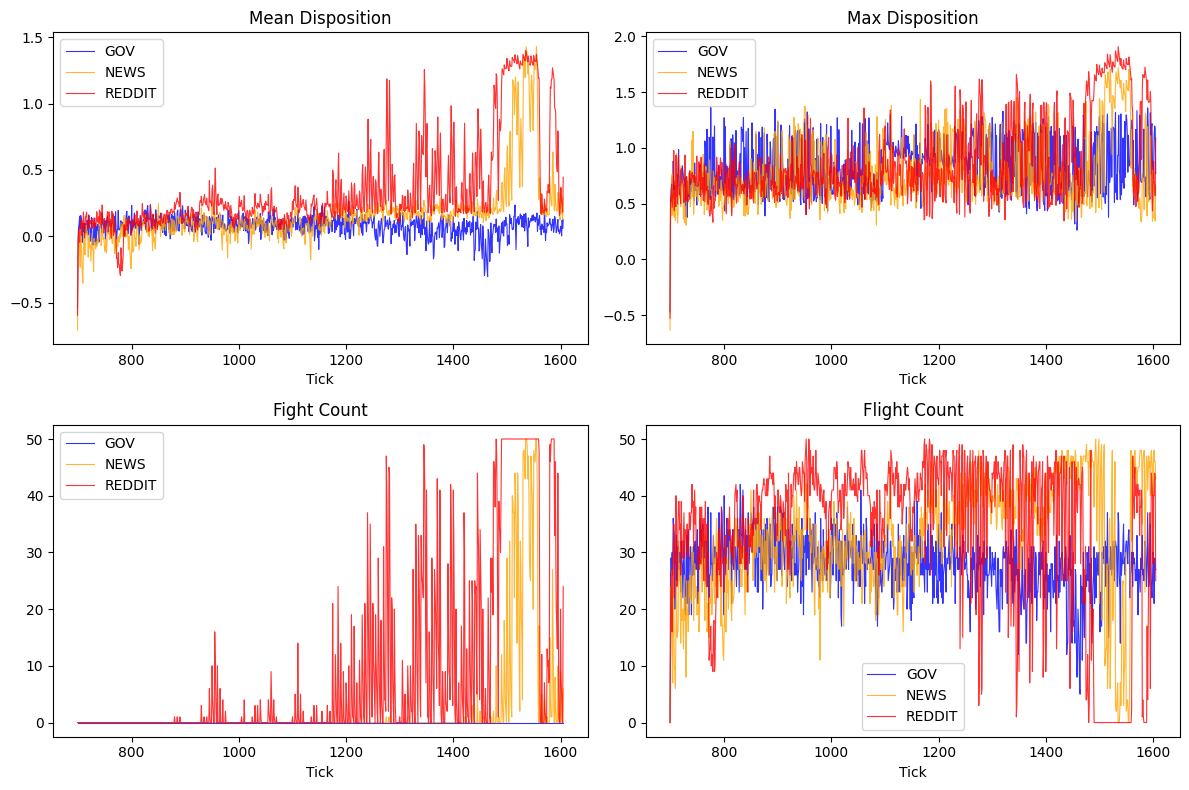

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

sim_start = 699
sim_end = 1606
total_steps = sim_end - sim_start
alpha = 0.10
colors = {'gov': 'blue', 'news': 'orange', 'reddit': 'red'}

ts = {}
for src in ['gov', 'news', 'reddit']:
    model = EnhancedPolarizationModel(ModelParameters(
        num_people=50, tau_base=0.5, tau_age_factor=0.003,
        tau_economic_factor=0.25, segregation_tolerance=0.25,
        rewire_prob=0.15, broadcast_interval=5))
    model.setup()
    model.tick = sim_start

    ts[src] = {'ticks': [], 'mean_d': [], 'max_d': [], 'fight': [], 'flight': []}

    for _ in range(total_steps):
        ext = get_source_signal(src, model.tick)
        for p in model.people:
            p.affect = (1 - alpha) * p.affect * 0.95 + alpha * ext
        model.step()

        disps = [p.disposition for p in model.people]
        ts[src]['ticks'].append(model.tick - 1)
        ts[src]['mean_d'].append(np.mean(disps))
        ts[src]['max_d'].append(np.max(disps))
        ts[src]['fight'].append(sum(1 for p in model.people if p.state == AgentState.FIGHT))
        ts[src]['flight'].append(sum(1 for p in model.people if p.state == AgentState.FLIGHT))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [('mean_d', 'Mean Disposition'), ('max_d', 'Max Disposition'),
           ('fight', 'Fight Count'), ('flight', 'Flight Count')]

for ax, (key, title) in zip(axes.flat, metrics):
    for src in ['gov', 'news', 'reddit']:
        ax.plot(ts[src]['ticks'], ts[src][key], label=src.upper(),
                color=colors[src], alpha=0.8, linewidth=0.8)
    ax.set_xlabel('Tick')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150)
plt.show()

# Export CSV
rows = []
for src in ['gov', 'news', 'reddit']:
    for i in range(len(ts[src]['ticks'])):
        rows.append({'source': src, 'tick': ts[src]['ticks'][i],
                      'mean_disp': ts[src]['mean_d'][i], 'max_disp': ts[src]['max_d'][i],
                      'fight': ts[src]['fight'][i], 'flight': ts[src]['flight'][i]})

pd.DataFrame(rows).to_csv('comparison_results.csv', index=False)

from google.colab import files
files.download('comparison_plot.png')
files.download('comparison_results.csv')

# New Section